# AutoKita Database Analysis

This notebook analyzes the 1,500 seeded job orders across all three scenarios:
- **Scenario B (New Cars)**: 0-5 years old, representing extremely low times and costs.
- **Baseline (Normal Cars)**: 6-11 years old, representing average times and costs.
- **Scenario A (Old Cars)**: 12+ years old, representing extreme high times and costs.

We will visualize the relationships and look at some key metrics.


In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

# Connect to database
conn = psycopg2.connect(host='localhost', user='postgres', password='paduding27', dbname='Capstone-Testing', port='5432')

# Query the job orders and vehicles
query = """
SELECT 
    EXTRACT(EPOCH FROM jos.actual_duration)/3600 AS duration_hours,
    jos.actual_amount AS cost,
    v.vehicle_year,
    2026 - CAST(v.vehicle_year AS INTEGER) AS vehicle_age,
    v.mileage,
    s.service_name,
    s.base_price,
    CASE 
        WHEN u.email LIKE '%highcost%' THEN 'Scenario A (Old Cars, 12+ yrs)'
        WHEN u.email LIKE '%lowcost%' THEN 'Scenario B (New Cars, 0-5 yrs)'
        ELSE 'Baseline (Normal Cars, 6-11 yrs)'
    END as scenario
FROM job_order_services jos
JOIN job_orders jo ON jos.job_order_id = jo.id
JOIN users u ON jo.user_id = u.id
JOIN vehicles v ON jo.vehicle_id = v.id
JOIN services s ON jos.service_id = s.id
WHERE jos.actual_duration IS NOT NULL AND jos.actual_amount IS NOT NULL;
"""

df = pd.read_sql(query, conn)
conn.close()

# Ensure mileage is numeric
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Preview the data
display(df.head())


,duration_hours,cost,vehicle_year,vehicle_age,mileage,service_name,base_price,scenario
0,2.550000,3814.208170,2020,6,23216.00,Oil Change,1500.0,"Baseline (Normal Cars, 6-11 yrs)"
1,1.450000,2047.177770,2025,1,17720.21,Engine Diagnostics,2000.0,"Scenario B (New Cars, 0-5 yrs)"
2,1.466667,1899.621872,2025,1,17720.21,Engine Diagnostics,2000.0,"Scenario B (New Cars, 0-5 yrs)"
3,1.333333,2526.591234,2025,1,20414.35,Engine Diagnostics,2000.0,"Scenario B (New Cars, 0-5 yrs)"
4,1.083333,1880.311476,2025,1,20414.35,Engine Diagnostics,2000.0,"Scenario B (New Cars, 0-5 yrs)"


## 1. Cost vs Time Scatterplot
Let's visualize how the actual cost scales directly with the time taken, separated by the age scenarios.

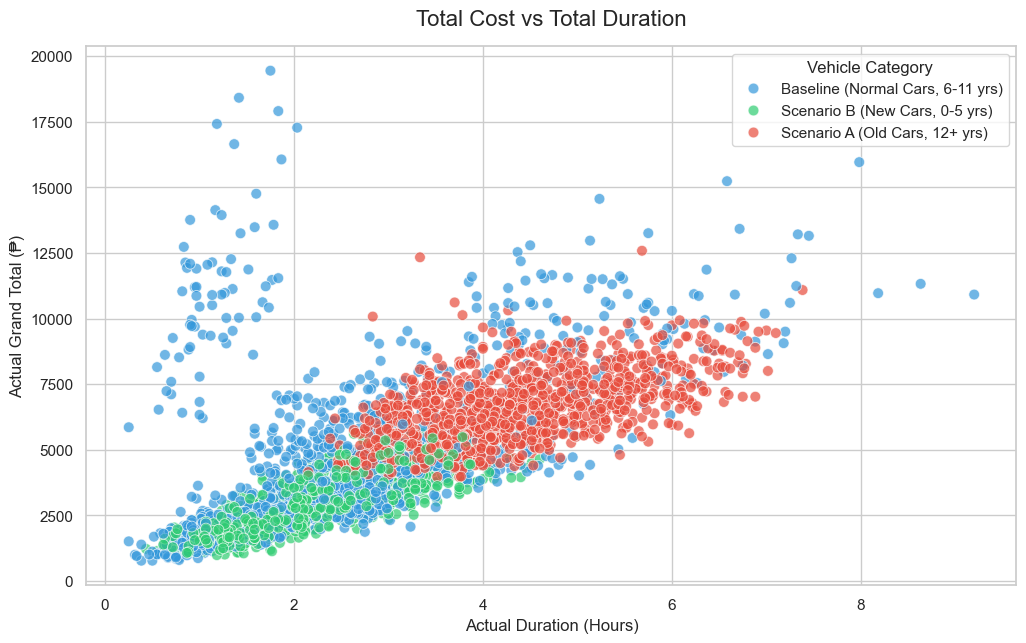

In [2]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='duration_hours', 
    y='cost', 
    hue='scenario', 
    palette={'Scenario A (Old Cars, 12+ yrs)': '#e74c3c', 'Baseline (Normal Cars, 6-11 yrs)': '#3498db', 'Scenario B (New Cars, 0-5 yrs)': '#2ecc71'},
    alpha=0.7,
    s=60
)

plt.title('Total Cost vs Total Duration', fontsize=16, pad=15)
plt.xlabel('Actual Duration (Hours)', fontsize=12)
plt.ylabel('Actual Grand Total (₱)', fontsize=12)
plt.legend(title='Vehicle Category')
plt.show()


## 2. Distribution Analysis (Boxplots)
To better understand the ranges and median values for both Time and Cost across the three categories.

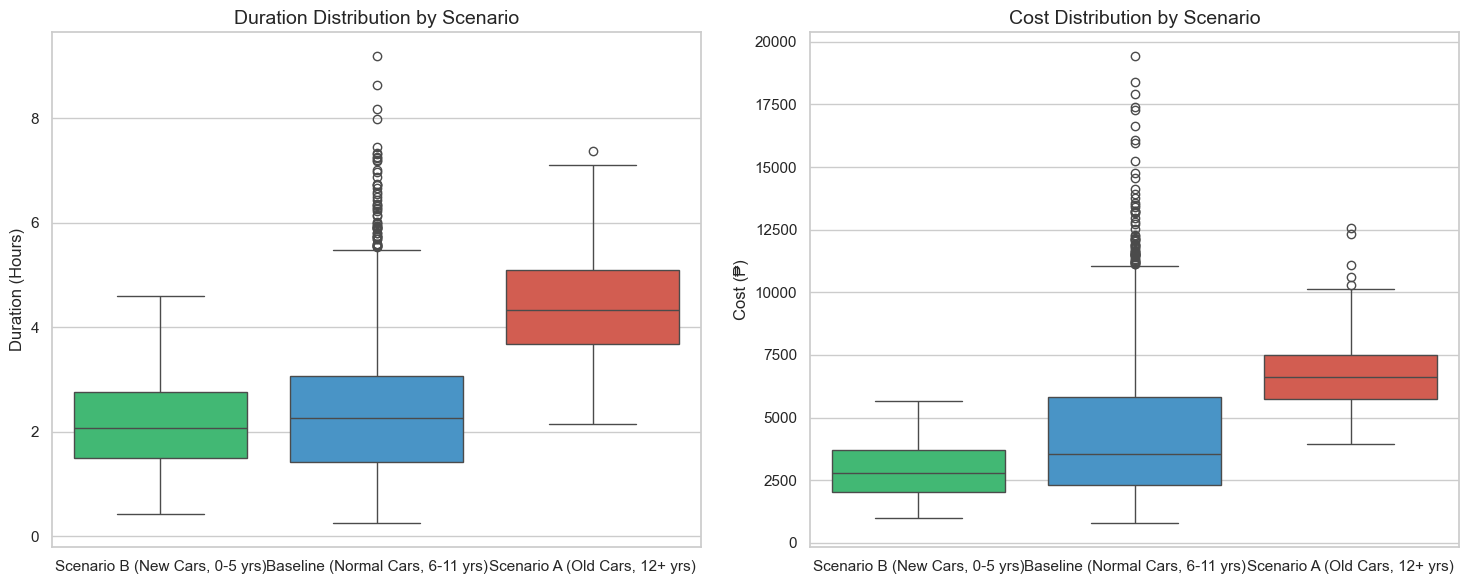

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = ['Scenario B (New Cars, 0-5 yrs)', 'Baseline (Normal Cars, 6-11 yrs)', 'Scenario A (Old Cars, 12+ yrs)']
palette = {'Scenario B (New Cars, 0-5 yrs)': '#2ecc71', 'Baseline (Normal Cars, 6-11 yrs)': '#3498db', 'Scenario A (Old Cars, 12+ yrs)': '#e74c3c'}

# Duration Boxplot
sns.boxplot(data=df, x='scenario', y='duration_hours', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Duration Distribution by Scenario', fontsize=14)
axes[0].set_ylabel('Duration (Hours)')
axes[0].set_xlabel('')

# Cost Boxplot
sns.boxplot(data=df, x='scenario', y='cost', order=order, palette=palette, ax=axes[1])
axes[1].set_title('Cost Distribution by Scenario', fontsize=14)
axes[1].set_ylabel('Cost (₱)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


## 3. Key Metrics Table
Aggregating the exact average multipliers per category.

In [4]:
metrics = df.groupby('scenario').agg({
    'duration_hours': ['mean', 'min', 'max'],
    'cost': ['mean', 'min', 'max'],
    'vehicle_age': 'mean'
}).reset_index()

metrics.columns = ['Scenario', 'Avg Duration (hrs)', 'Min Duration', 'Max Duration', 
                  'Avg Cost (₱)', 'Min Cost', 'Max Cost', 'Avg Vehicle Age']

metrics = metrics.round(2)
display(metrics)


,Scenario,Avg Duration (hrs),Min Duration,Max Duration,Avg Cost (₱),Min Cost,Max Cost,Avg Vehicle Age
0,"Baseline (Normal Cars, 6-11 yrs)",2.48,0.25,9.20,4517.38,772.88,19446.77,5.69
1,"Scenario A (Old Cars, 12+ yrs)",4.42,2.15,7.38,6679.52,3963.34,12583.53,13.05
2,"Scenario B (New Cars, 0-5 yrs)",2.17,0.43,4.60,2896.70,983.74,5646.32,2.45


## 4. Feature Correlation Matrix
Let's see numerically how strongly age and mileage correlate with the final time and cost.

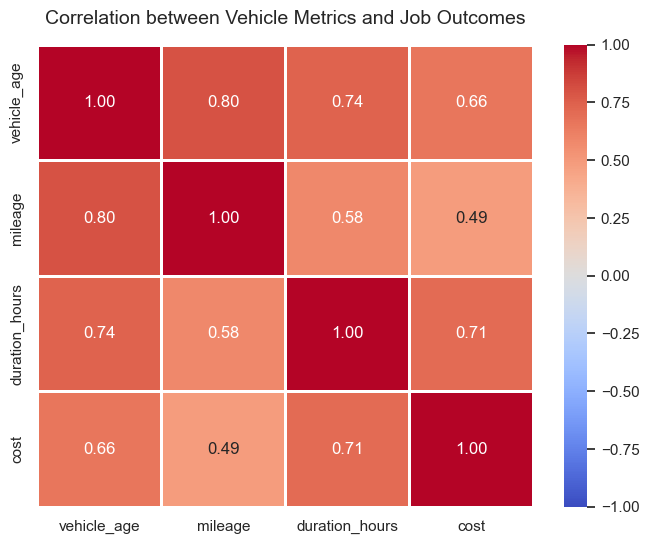

In [5]:
corr_cols = ['vehicle_age', 'mileage', 'duration_hours', 'cost']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=1)
plt.title('Correlation between Vehicle Metrics and Job Outcomes', fontsize=14, pad=15)
plt.show()


## 5. Impact of Service Type
This shows how the base difficulty (price) of a service heavily affects the final cost regardless of age.

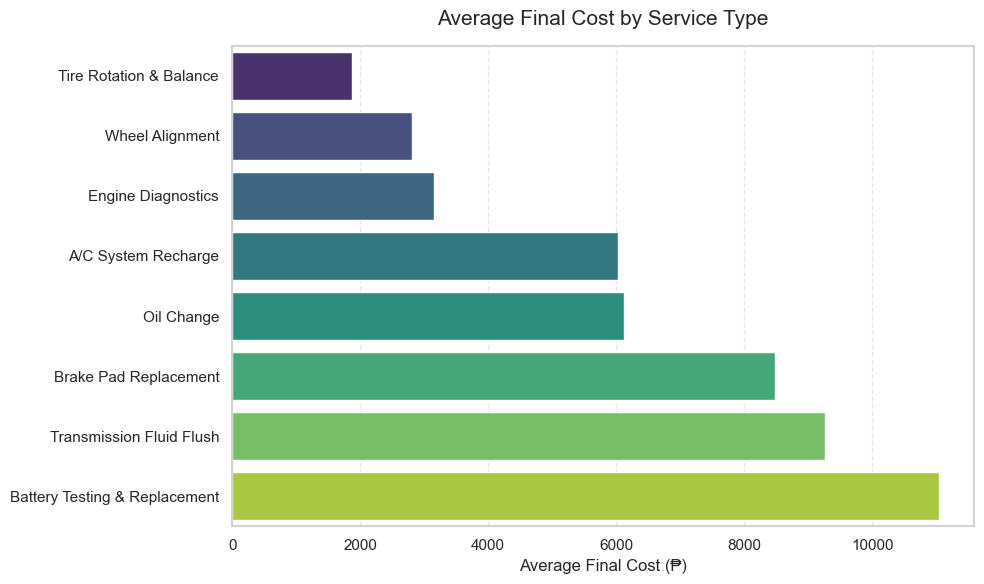

In [6]:
# Calculate the 'cost multiplier' to isolate mileage effect from service type base prices
df['cost_multiplier'] = df['cost'] / df['base_price'].astype(float)

plt.figure(figsize=(10, 6))
service_costs = df.groupby('service_name')['cost'].mean().sort_values(ascending=True)
sns.barplot(x=service_costs.values, y=service_costs.index, hue=service_costs.index, legend=False, palette='viridis')
plt.title('Average Final Cost by Service Type', fontsize=15, pad=15)
plt.xlabel('Average Final Cost (₱)', fontsize=12)
plt.ylabel('')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 6. Impact of Mileage (Isolated)
Filtering specifically for Normal Age cars (6-11 years old) to see if higher mileage alone increases cost.

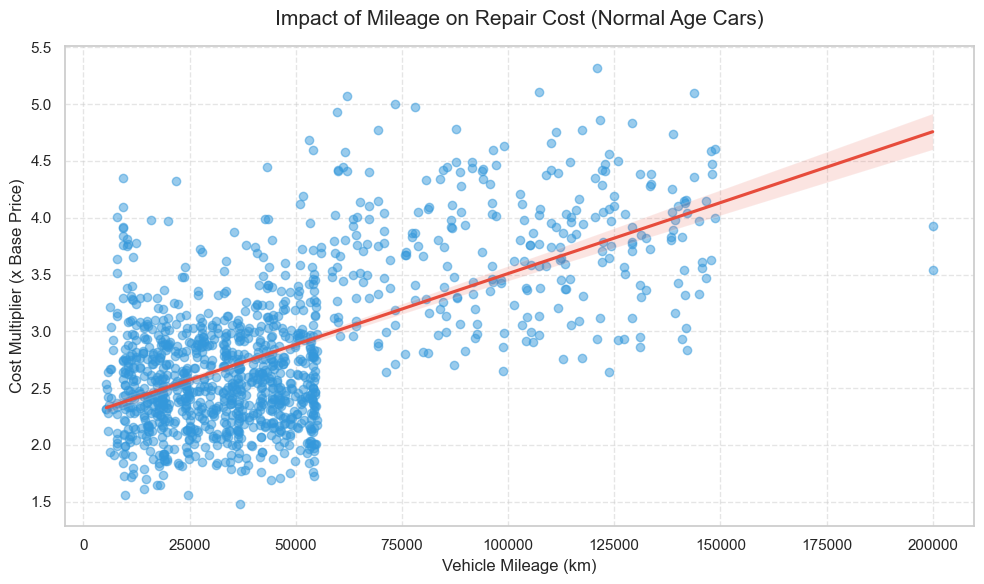

In [7]:
plt.figure(figsize=(10, 6))
# Filter for Normal age cars to isolate mileage effect from age effect
normal_cars = df[(df['vehicle_age'] >= 6) & (df['vehicle_age'] <= 11)]

sns.regplot(data=normal_cars, x='mileage', y='cost_multiplier', 
            scatter_kws={'alpha':0.5, 'color':'#3498db'}, 
            line_kws={'color':'#e74c3c'})
plt.title('Impact of Mileage on Repair Cost (Normal Age Cars)', fontsize=15, pad=15)
plt.xlabel('Vehicle Mileage (km)', fontsize=12)
plt.ylabel('Cost Multiplier (x Base Price)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 7. AI Model Feature Importance
Extracting the mathematical weights from the Random Forest model to see what it actually evaluates.

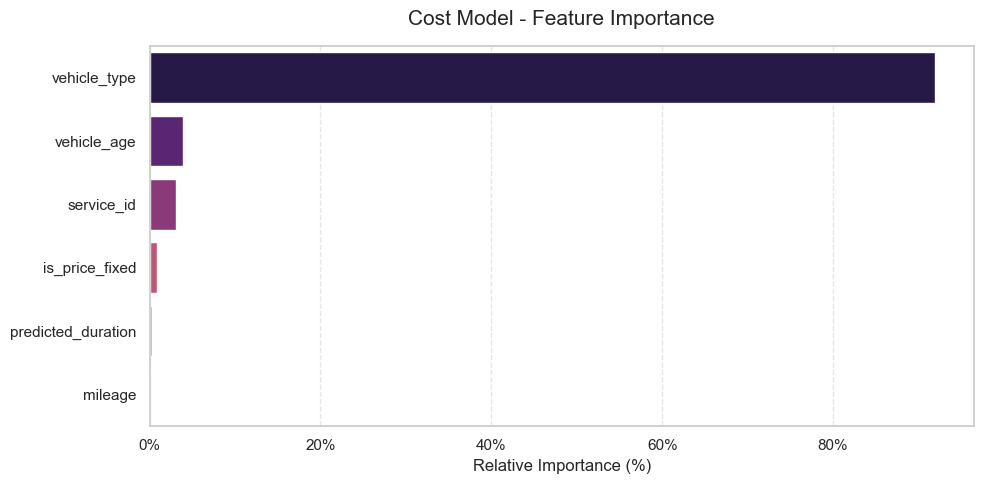

In [8]:
import joblib
import matplotlib.ticker as mtick

try:
    cost_model = joblib.load('exported/cost_model.pkl')
    importances = cost_model.feature_importances_
    features = ['vehicle_age', 'predicted_duration', 'mileage', 'vehicle_type', 'is_price_fixed', 'service_id']
    
    imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    imp_df = imp_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=imp_df, x='Importance', y='Feature', hue='Feature', legend=False, palette='magma')
    plt.title('Cost Model - Feature Importance', fontsize=15, pad=15)
    plt.xlabel('Relative Importance (%)', fontsize=12)
    plt.ylabel('')
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not load cost_model.pkl: {e}")
